In [1]:
from google.colab import drive
import zipfile
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path ="/content/drive/MyDrive/archive_cat_dog.zip"

In [4]:
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('/content/cat_dog_dataset')

In [5]:
data_dir ='/content/cat_dog_dataset'

In [6]:
print("Files in dataset folder:", os.listdir(data_dir))

Files in dataset folder: ['test_set', 'training_set']


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [8]:
# Load the VGG19 model without the top (fully connected) layers
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Freeze all convolutional layers
for layer in base_model.layers:
    layer.trainable = False

In [10]:
# Flatten the output of the convolutional base
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Add dropout to reduce overfitting
x = Dense(1, activation='sigmoid')(x)  # Binary classification

In [11]:
# Create the new model
model = Model(inputs=base_model.input, outputs=x)

In [12]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 26,447,425 (100.89 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [14]:
# Training and Validation Data Generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define ImageDataGenerator for training
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)  # 20% for validation

# Load Training Data (80% of train folder)
train_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',       # Path to training data C:\Users\IIITNAGPUR\Desktop\CV\datasets
    target_size=(224, 224), # Resize images
    batch_size=32,          # Batch size
    class_mode='binary',    # Binary classification (Cats vs. Dogs)
    subset='training'       # Use only training subset
)

# Load Validation Data (20% of train folder)
val_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'      # Use only validation subset
)

Found 6404 images belonging to 2 classes.
Found 1601 images belonging to 2 classes.


In [15]:
#Testing Data Generator (Without Validation Split)
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale, no split

test_generator = test_datagen.flow_from_directory(
    '/content/cat_dog_dataset/test_set/test_set',       # Path to test data
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',   # Or 'None' if test labels are unavailable
    shuffle=False          # Don't shuffle test data (important for predictions)
)

Found 2023 images belonging to 2 classes.


In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 66s 264ms/step - accuracy: 0.7619 - loss: 0.8569 - val_accuracy: 0.9007 - val_loss: 0.2383
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 50s 251ms/step - accuracy: 0.8895 - loss: 0.2669 - val_accuracy: 0.9019 - val_loss: 0.2220
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 52s 259ms/step - accuracy: 0.9031 - loss: 0.2263 - val_accuracy: 0.8851 - val_loss: 0.2545
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 52s 257ms/step - accuracy: 0.9051 - loss: 0.2200 - val_accuracy: 0.9119 - val_loss: 0.1970
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 52s 258ms/step - accuracy: 0.9264 - loss: 0.1854 - val_accuracy: 0.9088 - val_loss: 0.2115
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 52s 258ms/step - accuracy: 0.9292 - loss: 0.1754 - val_accuracy: 0.9051 - val_loss: 0.2075
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 62s 309ms/step - accuracy: 0.9393 - loss: 0.1507 - val_accuracy: 0.9144 - val_loss: 0.2223
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 63s 311ms/step - accuracy: 0.9333 - loss: 0.1530 - val

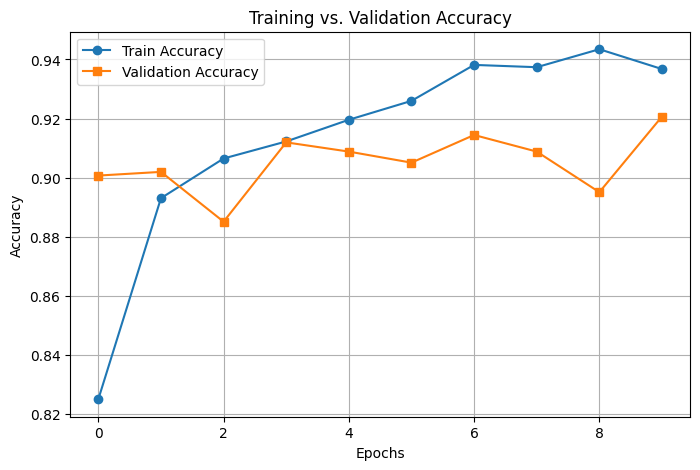

In [17]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.8916 - loss: 0.2770
Test accuracy: 0.9115
